# 1. Case Study Selection

## Use Case: Second Hand Car Market Analysis

This project focuses on analyzing used car resale data to understand pricing patterns, depreciation behavior, and brand performance.

The used car market is highly competitive and price-sensitive, making it suitable for exploratory data analysis and business insight generation.

# 2. Search for Relevant Websites

Several online automobile resale platforms were reviewed, including:

- Cars24
- CarDekho
- Spinny
- OLX Autos

## Selected Platform: Cars24

Cars24 was selected due to:

- Structured listing format
- Availability of key attributes (Price, Brand, Year, KM, Fuel Type, Transmission, Ownership, City)
- Large inventory across cities

Over 3000 used car listings were scraped for analysis.

# 3. Problem Statement

## Objective

To perform brand-wise exploratory data analysis (EDA) on used car listings and identify pricing patterns, depreciation trends, and market positioning.

## Target Variable
- Price (Resale Value)

## Key Features
- Brand
- Year / Car Age
- Kilometers Driven
- Fuel Type
- Transmission
- Ownership
- Mileage
- Engine
- City

## Key Questions

- Which brands retain resale value better?
- How does car age affect price?
- What is the impact of kilometers driven?
- Do automatic cars command a premium?
- How are brands distributed across price segments?

# 4. Extract the Data

To address the business objective of brand-wise resale analysis, structured listing data was scraped from Cars24 across multiple cities and car brands.

## Data Collection Strategy

- Multiple cities were targeted to avoid regional bias.
- Multiple brands were selected to enable brand-wise comparison.
- Dynamic URLs were generated for each city–brand combination.
- HTTP requests were sent using custom headers.
- HTML content was parsed using BeautifulSoup.
- Key attributes were extracted using regex patterns and HTML selectors.

## Features Extracted

The following variables were collected to support resale price analysis:

- Brand  
- Variant  
- Model Year  
- City  
- Kilometer Driven  
- Price  
- EMI  
- Fuel Type  
- Drive Mode (Transmission)

These features were selected because they directly or indirectly influence resale price and help analyze depreciation, usage impact, and market positioning.

## Dataset Size

- 3000+ used car listings collected  
- 9 key variables extracted  

The dataset satisfies the requirement of minimum 400 rows and 8+ features, enabling meaningful exploratory analysis and business insight generation.

### Importing Required Libraries

The following Python libraries are used for web scraping, data handling, and visualization:

- `requests` is used to send HTTP requests to the Cars24 website.
- `BeautifulSoup` from `bs4` is used to parse and extract HTML content.
- `re` (Regular Expressions) is used to extract structured information from unstructured text.
- `pandas` is used to store and manipulate the scraped data in tabular form.
- `matplotlib` and `seaborn` are imported for data visualization during the EDA phase.

In [27]:
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Defining Request Headers

A user-agent header is defined to simulate a browser request and avoid request blocking while accessing public web content.

In [2]:
request_header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36"
}

### Defining Cities and Brands

A list of major Indian cities and popular car brands is defined to enable brand-wise and city-wise data collection from Cars24.

In [3]:
cities = {
    'hyderabad':3686,'bangalore':4709,'mumbai':2378,'pune':2423,'chennai':5732, 'new-delhi': 2, 'surat': 1605, 'agra': 136,
    'kochi':6356,'ahmedabad':1692,'lucknow':290,'jaipur':2130,'kolkata':777,'noida':134, 'coimbatore': 6105,
}

cars = ['tata','honda','maruti','hyundai','ford','mahindra','bmw','toyota', 'renault', 'kia', 'volkswagen']

### Iterating Over Cities and Brands

A nested loop is used to iterate through each city and car brand.  
For every city–brand combination, a Cars24 listing URL is dynamically constructed to fetch used-car listings relevant to that brand and location.

In [60]:
rows = []  # List to store scraped car records

# Iterate over each city and car brand
for city in cities:
    for car in cars:
        # Construct Cars24 listing URL for the given city and brand
        url = f"https://www.cars24.com/buy-used-{car}-cars-{city}/?sort=bestmatch&serveWarrantyCount=true&storeCityId={cities[city]}"
        print("Scraping:", url)

        # Send HTTP request and parse HTML response
        page = requests.get(url, headers=request_header)
        soup = BeautifulSoup(page.text, "html.parser")

        # Extract individual car listing blocks
        for block in soup.find_all("div", class_="styles_outer__NTVth"):
            # Clean raw text content from the listing
            text = block.text.replace("\xa0", " ").strip()

            # Extract car attributes using regex and HTML elements
            row = {
                "Brand": re.findall(r'\d{4}\s(\w+)', text)[0] if re.findall(r'\d{4}\s(\w+)', text) else None,
                "Variant": re.findall(r'\d{4}\s\w+\s(.+?)(?:\d*,*\d*,*\d{3} km)', text)[0] if re.findall(r'\d{4}\s\w+\s(.+?)(\d*,*\d*,*\d{3} km)', text) else None,
                "Model Year": re.findall(r'^\d{4}', text)[0] if re.findall(r'^\d{4}', text) else None,
                "City": city.capitalize(),   # Assign city name
                "Kilometer": re.findall(r'(\d{1,3}(?:,\d{3})* km)', text)[0] if re.findall(r'(\d{1,3}(?:,\d{3})* km)', text) else None,
                "Price": block.find("div", class_="styles_priceWrap__VwWBV").text.strip() if block.find("div", class_="styles_priceWrap__VwWBV") else None,
                "EMI": block.find("div", class_="styles_flexItem__2z__J").text.strip() if block.find("div", class_="styles_flexItem__2z__J") else None,
                "Fuel_Type": re.findall(r'(Petrol|Diesel|Electric|CNG)', text)[0] if re.findall(r'(Petrol|Diesel|Electric|CNG)', text) else None,
                "Drive_Mode": re.findall(r'(Manual|Auto)', text)[0] if re.findall(r'(Manual|Auto)', text) else None,
            }

            # Append extracted record to the dataset
            rows.append(row)


Scraping: https://www.cars24.com/buy-used-tata-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-honda-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-maruti-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-hyundai-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-ford-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-mahindra-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-bmw-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-used-toyota-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686
Scraping: https://www.cars24.com/buy-

# 5. Creating the DataFrame

After completing the web scraping process, the extracted car listing records are converted into a structured Pandas DataFrame. This tabular format enables efficient data inspection, cleaning, and analysis in subsequent steps.

In [61]:
df = pd.DataFrame(rows)
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,"55,160 km",₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,"84,719 km",₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,"34,483 km",₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,"46,327 km",₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,"98,516 km",₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3147,Volkswagen,Vento COMFORTLINE 1.,2011,Coimbatore,"695,604 km",₹1.09 lakh,Not available on EMI,Petrol,Manual
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,"55,404 km",₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,"53,441 km",₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,"94,479 km",₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


# 6. Exporting the Dataset to CSV

The structured dataset is exported to a CSV file for persistence and reuse. Storing the scraped data in CSV format allows the data to be reloaded independently of the web scraping process.

In [62]:
df.to_csv("Cars24_Used_Cars_Raw_Data.csv", index=False)

# 7. Reading the CSV File

The exported CSV file is reloaded to verify data integrity and to begin the data understanding and cleaning process.

In [63]:
df = pd.read_csv("Cars24_Used_Cars_Raw_Data.csv")
df.head()

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,"55,160 km",₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,"84,719 km",₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,"34,483 km",₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,"46,327 km",₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,"98,516 km",₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual


# 8. Data Understanding

Before performing data cleaning and exploratory analysis, it is essential to understand the structure, content, and quality of the dataset. This section focuses on inspecting the dataset without making any modifications.

In [64]:
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,"55,160 km",₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,"84,719 km",₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,"34,483 km",₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,"46,327 km",₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,"98,516 km",₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3147,Volkswagen,Vento COMFORTLINE 1.,2011,Coimbatore,"695,604 km",₹1.09 lakh,Not available on EMI,Petrol,Manual
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,"55,404 km",₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,"53,441 km",₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,"94,479 km",₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


### Data Types and Missing Values

The data types of each column and the count of non-null values are examined to identify potential data quality issues.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3152 entries, 0 to 3151
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Brand       3152 non-null   object
 1   Variant     3152 non-null   object
 2   Model Year  3152 non-null   int64 
 3   City        3152 non-null   object
 4   Kilometer   3152 non-null   object
 5   Price       3152 non-null   object
 6   EMI         3152 non-null   object
 7   Fuel_Type   3139 non-null   object
 8   Drive_Mode  3152 non-null   object
dtypes: int64(1), object(8)
memory usage: 221.8+ KB


### Missing Values Summary

The number of missing values in each column is calculated to understand the extent of missing data.

In [66]:
df.isna().sum()

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64

### Duplicate Records

The dataset is checked for duplicate records that may have occurred during the web scraping process.

In [67]:
df.duplicated().sum()

np.int64(0)

### Statistical Summary of All Features

In [68]:
df.describe(include='all')

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
count,3152,3152,3152.000000,3152,3152,3152,3152,3139,3152
unique,11,1007,NaN,15,2875,2350,2040,4,2
top,Maruti,Ecosport TITANIUM 1.5L DIESEL,NaN,New-delhi,"00,000 km",₹5.10 lakh,Not available on EMI,Petrol,Manual
freq,340,46,NaN,406,4,8,206,2134,2349
mean,NaN,NaN,2018.112627,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.528234,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN


### Value Counts of Key Categorical Features

Frequency distributions of important categorical variables are examined to support brand-wise analysis.

In [69]:
print(df['Brand'].value_counts(), '\n')
print(df['City'].value_counts(), '\n')
print(df['Fuel_Type'].value_counts(), '\n')
print(df['Drive_Mode'].value_counts())

Brand
Maruti        340
Tata          338
Hyundai       331
Honda         327
Mahindra      306
Renault       300
Ford          293
KIA           280
Toyota        274
Volkswagen    257
BMW           106
Name: count, dtype: int64 

City
New-delhi     406
Noida         401
Hyderabad     219
Mumbai        214
Bangalore     209
Pune          208
Ahmedabad     207
Chennai       199
Kolkata       187
Lucknow       185
Jaipur        176
Agra          159
Surat         152
Kochi         137
Coimbatore     93
Name: count, dtype: int64 

Fuel_Type
Petrol      2134
Diesel       877
CNG          122
Electric       6
Name: count, dtype: int64 

Drive_Mode
Manual    2349
Auto       803
Name: count, dtype: int64


# 9. Data Cleaning

The scraped dataset contains raw text values, inconsistent formats, and missing entries that must be cleaned before analysis. This section focuses on transforming the data into a structured and analysis-ready format while preserving meaningful information.

### Handling Missing Values

In [70]:
print(df.isna().sum())
print(df.shape)

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64
(3152, 9)


In [71]:
df[df["Fuel_Type"].isnull()]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
568,Toyota,Camry HYBRID,2021,Mumbai,"39,751 km",₹30.75L₹28.90 lakh,"EMI ₹49,484/m*",NaN,Auto
782,Toyota,URBAN CRUISER HYRYDER V HYBRID,2023,Pune,"60,430 km",₹17.00 lakh,"EMI ₹29,108/m*",NaN,Auto
783,Toyota,Camry HYBRID,2016,Pune,"23,698 km",₹13.60 lakh,"EMI ₹29,570/m*",NaN,Auto
1298,Toyota,Camry HYBRID,2024,New-delhi,"5,399 km",₹39.50L₹38.00 lakh,"EMI ₹65,065/m*",NaN,Auto
1299,Toyota,Camry HYBRID,2023,New-delhi,"15,756 km",₹34.90L₹34.00 lakh,"EMI ₹58,216/m*",NaN,Auto
1317,Toyota,Camry HYBRID,2016,New-delhi,"67,776 km",₹9.62 lakh,"EMI ₹20,918/m*",NaN,Auto
1568,Toyota,Camry HYBRID,2018,Surat,"74,333 km",₹11.85L₹11.00 lakh,"EMI ₹18,835/m*",NaN,Auto
2602,Toyota,Camry HYBRID,2017,Kolkata,"42,258 km",₹11.71L₹11.20 lakh,"EMI ₹21,318/m*",NaN,Auto
2604,Toyota,URBAN CRUISER HYRYDER V HYBRID,2022,Kolkata,"35,948 km",₹13.75 lakh,"EMI ₹23,543/m*",NaN,Auto
2605,Toyota,INNOVA HYCROSS ZX HYBRID 7 STR,2023,Kolkata,"63,922 km",₹21.35 lakh,"EMI ₹36,556/m*",NaN,Auto


### Missing Value Treatment – Fuel_Type

- All missing Fuel_Type values were observed in Toyota listings.
- Since the proportion of missing values was very small (0.41% of total dataset),
- these rows were removed to maintain dataset integrity without introducing bias.

In [72]:
# Drop rows where Fuel_Type is null
df = df.dropna(subset=["Fuel_Type"])

### Reset index after dropping rows

In [73]:
df = df.reset_index(drop=True)

### Cleaning the Kilometer Column

The `Kilometer` column is stored as text with units and commas. It is cleaned by removing non-numeric characters and converting it into a numeric format.

In [74]:
df['Kilometer'] = (
    df['Kilometer']
    .str.replace(' km', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [75]:
df['Kilometer']

0        55160
1        84719
2        34483
3        46327
4        98516
         ...  
3134    695604
3135     55404
3136     53441
3137     94479
3138     21165
Name: Kilometer, Length: 3139, dtype: int64

In [91]:
df["Kilometer"].quantile([0.90, 0.95, 0.99])

0.90     95700.60
0.95    269012.80
0.99    866555.28
Name: Kilometer, dtype: float64

In [94]:
df = df[df["Kilometer"] <= 600000]
df = df.reset_index(drop=True)

### Kilometer Distribution Analysis

The 95th percentile of kilometer values was approximately 269,000 km,
while the 99th percentile jumped to 866,000 km, indicating a heavy
right-skewed distribution.

To reduce distortion caused by extreme high-mileage vehicles,
a domain-based threshold of 600,000 km was applied.

In [95]:
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3068,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto
3069,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual
3070,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3071,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


In [93]:
df2["Kilometer"].quantile(0.99)

np.float64(529291.4799999996)

### Cleaning Price and Creating Target Variable

The `Price` column contains inconsistent text values, including multiple prices in some cases. To ensure consistency, a clean numeric target variable named `Final_Price` is extracted.
When multiple prices are present, the discounted (last) price is considered for analysis.

In [99]:
price_values = df['Price'].str.findall(r'(\d+\.?\d*)')

df['Final_Price'] = price_values.apply(
    lambda x: float(x[-1]) * 100000 if x else None)

In [100]:
df['Final_Price'] = df['Final_Price'].astype(int)

In [101]:
df["Final_Price"]

0        259000
1        505000
2        304000
3        151000
4        260000
         ...   
3068    1094000
3069     239000
3070     933000
3071     366000
3072     401000
Name: Final_Price, Length: 3073, dtype: int64

### Dropping Raw Price Column

After extracting the clean numeric price, the original `Price` column is removed to avoid confusion and redundancy.

In [103]:
df.drop(columns=['Price'], inplace=True)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Brand        3073 non-null   object
 1   Variant      3073 non-null   object
 2   Model Year   3073 non-null   int64 
 3   City         3073 non-null   object
 4   Kilometer    3073 non-null   int64 
 5   EMI          3073 non-null   object
 6   Fuel_Type    3073 non-null   object
 7   Drive_Mode   3073 non-null   object
 8   Final_Price  3073 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 216.2+ KB


### Cleaning EMI Column

The `EMI` column contains text values and missing entries. The numeric EMI amount is extracted and converted into a numeric format. Non-available values are treated as missing.

In [106]:
df['EMI'] = df['EMI'].str.extract(r'₹([\d,]+)')
df['EMI'] = df['EMI'].str.replace(',', '', regex=False)
df['EMI'] = pd.to_numeric(df['EMI'], errors='coerce')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brand        3073 non-null   object 
 1   Variant      3073 non-null   object 
 2   Model Year   3073 non-null   int64  
 3   City         3073 non-null   object 
 4   Kilometer    3073 non-null   int64  
 5   EMI          2873 non-null   float64
 6   Fuel_Type    3073 non-null   object 
 7   Drive_Mode   3073 non-null   object 
 8   Final_Price  3073 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 216.2+ KB


## Car_Age

Car_Age is calculated as:

Car_Age = 2026 − Model Year

This feature helps analyze depreciation and understand the lifecycle of vehicles.

## KM_per_Year

KM_per_Year represents the average yearly usage of the vehicle.

KM_per_Year = Kilometer / Car_Age

It helps measure usage intensity and wear level.

In [117]:
df["Car_Age"] = 2026 - df["Model Year"]
df["KM_per_Year"] = round(df["Kilometer"] / df["Car_Age"], 1)

## Price_Segment

Vehicles are categorized into price ranges:

- Budget: 0–5L
- Mid: 5–10L
- Upper-Mid: 10–20L
- Premium: 20L+

This helps in market segmentation and positioning analysis.

In [128]:
bins = [0,500000,1000000,2000000,10000000]
labels = ["Budget","Mid","Upper-Mid","Premium"]
df["Price_Segment"] = pd.cut(df["Final_Price"], bins=bins, labels=labels)

In [129]:
df["Price_Segment"].value_counts(normalize=True) * 100

Price_Segment
Budget       57.403189
Mid          30.946957
Upper-Mid     9.762447
Premium       1.887406
Name: proportion, dtype: float64

## Age_Bucket

Vehicles are grouped into age ranges:

- 0–3 years
- 4–6 years
- 7–10 years
- 10+ years

This simplifies depreciation and comparative analysis.

In [121]:
df["Age_Bucket"] = pd.cut(df["Car_Age"],
                          bins=[0,3,6,10,20],
                          labels=["0-3","4-6","7-10","10+"])

## Final Dataset Ready for Analysis

In [124]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,KM_per_Year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000,10,9851.6,Budget,7-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000,4,22243.5,Upper-Mid,4-6
3069,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000,15,3693.6,Budget,10+
3070,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000,5,10688.2,Mid,4-6
3071,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000,11,8589.0,Budget,10+


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Brand          3073 non-null   object  
 1   Variant        3073 non-null   object  
 2   Model Year     3073 non-null   int64   
 3   City           3073 non-null   object  
 4   Kilometer      3073 non-null   int64   
 5   EMI            2873 non-null   float64 
 6   Fuel_Type      3073 non-null   object  
 7   Drive_Mode     3073 non-null   object  
 8   Final_Price    3073 non-null   int64   
 9   Car_Age        3073 non-null   int64   
 10  KM_per_Year    3073 non-null   float64 
 11  Price_Segment  3073 non-null   category
 12  Age_Bucket     3073 non-null   category
dtypes: category(2), float64(2), int64(4), object(5)
memory usage: 270.6+ KB


## Column Description

| Column Name   | Data Type | Description |
|--------------|-----------|-------------|
| Brand        | Categorical | Car manufacturer (e.g., Maruti, Hyundai, BMW). Used for brand-wise comparison. |
| Variant      | Categorical | Specific model/variant of the car within a brand. |
| Model Year   | Numerical | Manufacturing year of the vehicle. Used to calculate car age and depreciation. |
| City         | Categorical | Location where the car is listed. Helps analyze regional distribution. |
| Kilometer    | Numerical (after cleaning) | Total distance driven (in km). Indicates vehicle usage intensity. |
| EMI          | Numerical (after cleaning) | Estimated monthly installment value. Reflects financing aspect. |
| Fuel_Type    | Categorical | Type of fuel used (Petrol, Diesel, CNG, Electric). |
| Drive_Mode   | Categorical | Transmission type (Manual or Automatic). |
| Final_Price  | Numerical (after cleaning)| Resale price of the car (target variable). |

## Derived Columns

| Column Name   | Data Type | Description |
|--------------|-----------|-------------|
| Car_Age      | Numerical | Calculated as Current Year - Model Year. Used for depreciation analysis. |
| KM_per_Year  | Numerical | Kilometers driven per year. Measures usage intensity. |
| Price_Segment| Categorical | Categorized price range (Budget, Mid, Premium). Used for market positioning. |
| Age_Bucket   | Categorical | Grouped car age ranges (0-3, 4-6, etc.) for depreciation study. |

In [133]:
df.to_csv("Cars24_Used_Cars_Clean_Data.csv", index = False)

In [134]:
df = pd.read_csv("Cars24_Used_Cars_Clean_Data.csv")

In [135]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,KM_per_Year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000,10,9851.6,Budget,7-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000,4,22243.5,Upper-Mid,4-6
3069,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000,15,3693.6,Budget,10+
3070,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000,5,10688.2,Mid,4-6
3071,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000,11,8589.0,Budget,10+


# 10. Exploratory Data Analysis (EDA)

Now that the data is cleaned, we will explore it visually to find patterns and insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cars24_Used_Cars_Clean_Data.csv")
print(df.shape)
df.head()

(3073, 13)


,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,KM_per_Year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000,10,9851.6,Budget,7-10


# 11. Univariate Analysis

Looking at each column individually to understand its distribution.

## 11.1 Distribution of Resale Price

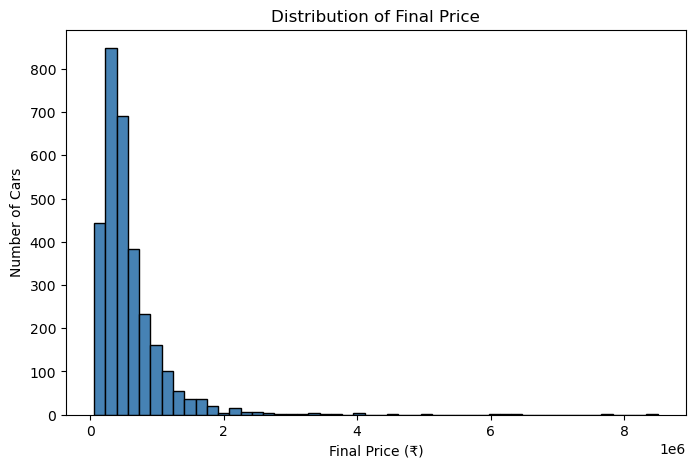

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df['Final_Price'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Price')
plt.xlabel('Final Price (₹)')
plt.ylabel('Number of Cars')
plt.show()

**Observation:** The price distribution is right-skewed. Most cars are priced below ₹5 Lakhs, which means budget cars dominate the used car market.

## 11.2 Distribution of Kilometers Driven

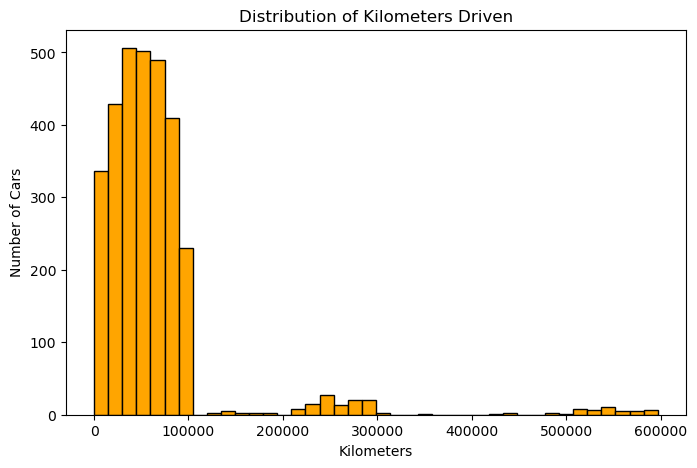

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df['Kilometer'], bins=40, color='orange', edgecolor='black')
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers')
plt.ylabel('Number of Cars')
plt.show()

**Observation:** Most cars have been driven between 30,000 to 80,000 km. Very few cars have extremely high mileage.

## 11.3 Distribution of Car Age

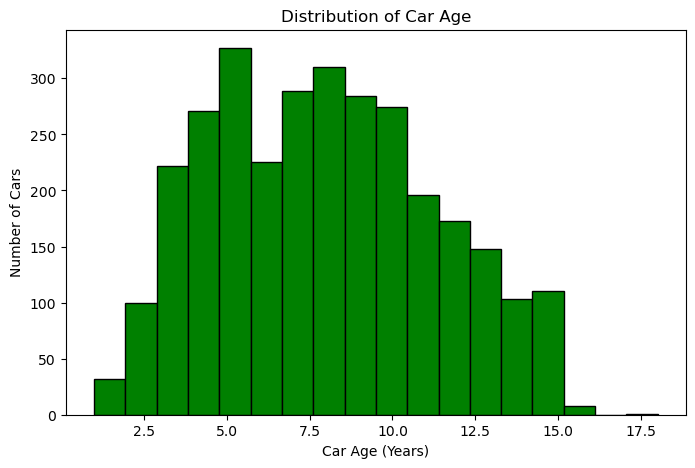

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df['Car_Age'], bins=18, color='green', edgecolor='black')
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Number of Cars')
plt.show()

**Observation:** Most cars in the dataset are 5 to 10 years old, which is typical for the second-hand car market.

## 11.4 Fuel Type Count

Fuel_Type
Petrol      2100
Diesel       846
CNG          121
Electric       6
Name: count, dtype: int64


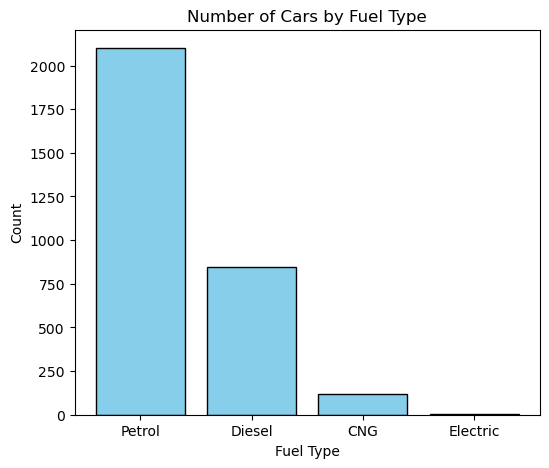

In [6]:
fuel_counts = df['Fuel_Type'].value_counts()
print(fuel_counts)

plt.figure(figsize=(6, 5))
plt.bar(fuel_counts.index, fuel_counts.values, color='skyblue', edgecolor='black')
plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.show()

**Observation:** Petrol cars are the most common, followed by Diesel. CNG and Electric are very small in proportion.

## 11.5 Transmission Type Count

Drive_Mode
Manual    2283
Auto       790
Name: count, dtype: int64


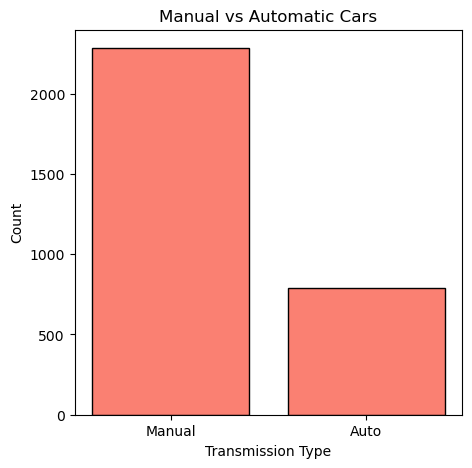

In [7]:
drive_counts = df['Drive_Mode'].value_counts()
print(drive_counts)

plt.figure(figsize=(5, 5))
plt.bar(drive_counts.index, drive_counts.values, color='salmon', edgecolor='black')
plt.title('Manual vs Automatic Cars')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

**Observation:** Manual cars are much more common than Automatic cars in the used car market.

## 11.6 Price Segment Distribution

Price_Segment
Budget       1764
Mid           951
Upper-Mid     300
Premium        58
Name: count, dtype: int64


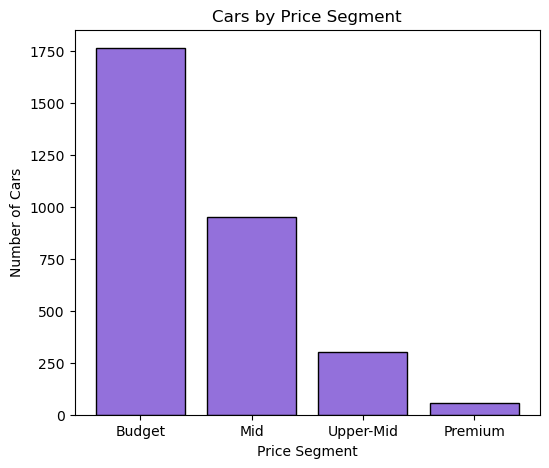

In [8]:
seg_counts = df['Price_Segment'].value_counts()
print(seg_counts)

plt.figure(figsize=(6, 5))
plt.bar(seg_counts.index, seg_counts.values, color='mediumpurple', edgecolor='black')
plt.title('Cars by Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Number of Cars')
plt.show()

**Observation:** Budget segment has the highest number of cars. Premium segment has very few listings.

# 12. Bivariate Analysis

Here we compare two columns together to find relationships.

## 12.1 Brand-Wise Average Resale Price

Brand
BMW           1.570500e+06
KIA           9.959428e+05
Mahindra      7.988231e+05
Toyota        7.511877e+05
Tata          5.781272e+05
Hyundai       4.894622e+05
Honda         4.389694e+05
Volkswagen    4.216279e+05
Maruti        3.827735e+05
Ford          3.676552e+05
Renault       3.367814e+05
Name: Final_Price, dtype: float64


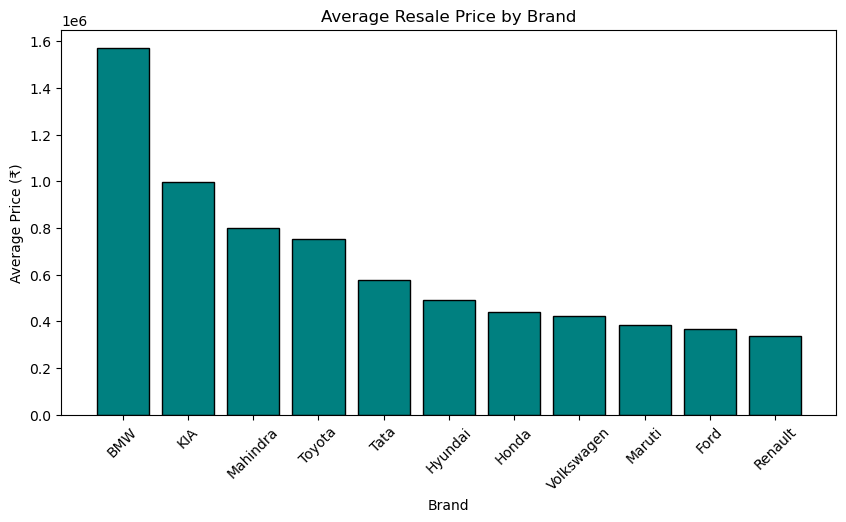

In [9]:
brand_avg_price = df.groupby('Brand')['Final_Price'].mean()
brand_avg_price = brand_avg_price.sort_values(ascending=False)
print(brand_avg_price)

plt.figure(figsize=(10, 5))
plt.bar(brand_avg_price.index, brand_avg_price.values, color='teal', edgecolor='black')
plt.title('Average Resale Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45)
plt.show()

**Observation:** BMW has the highest average resale price. Renault and Ford have the lowest. This shows that luxury brands retain higher resale value.

## 12.2 Car Age vs Resale Price (Scatter Plot)

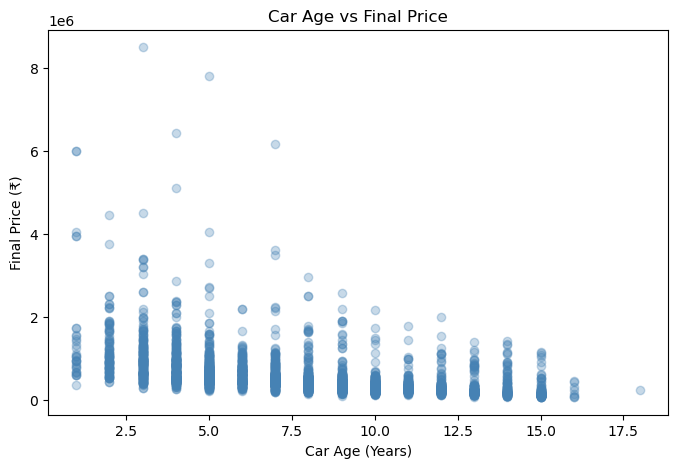

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Car_Age'], df['Final_Price'], alpha=0.3, color='steelblue')
plt.title('Car Age vs Final Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Final Price (₹)')
plt.show()

**Observation:** As car age increases, the resale price generally decreases. Newer cars are priced much higher than older ones.

## 12.3 Kilometers Driven vs Resale Price

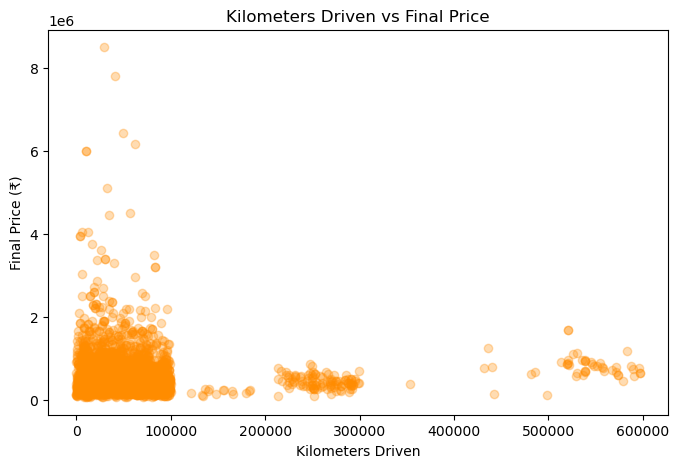

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Kilometer'], df['Final_Price'], alpha=0.3, color='darkorange')
plt.title('Kilometers Driven vs Final Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Final Price (₹)')
plt.show()

**Observation:** Cars with lower kilometers driven are priced higher. This confirms that mileage is a key factor in determining resale value.

## 12.4 Average Price by Fuel Type

Fuel_Type
CNG         4.400660e+05
Diesel      7.715118e+05
Electric    1.426000e+06
Petrol      5.158733e+05
Name: Final_Price, dtype: float64


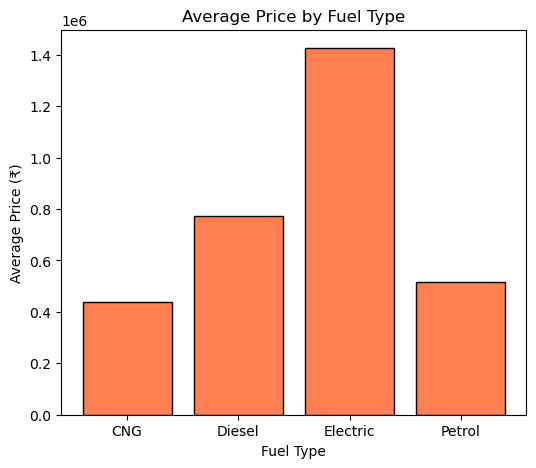

In [12]:
fuel_avg = df.groupby('Fuel_Type')['Final_Price'].mean()
print(fuel_avg)

plt.figure(figsize=(6, 5))
plt.bar(fuel_avg.index, fuel_avg.values, color='coral', edgecolor='black')
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (₹)')
plt.show()

**Observation:** Electric cars have the highest average resale price, but there are very few of them. Diesel cars are priced higher than Petrol cars on average.

## 12.5 Average Price by Transmission Type

Drive_Mode
Auto      908948.051899
Manual    472960.075339
Name: Final_Price, dtype: float64


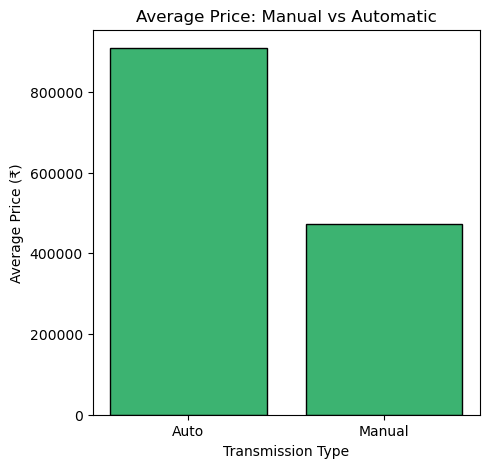

In [13]:
drive_avg = df.groupby('Drive_Mode')['Final_Price'].mean()
print(drive_avg)

plt.figure(figsize=(5, 5))
plt.bar(drive_avg.index, drive_avg.values, color='mediumseagreen', edgecolor='black')
plt.title('Average Price: Manual vs Automatic')
plt.xlabel('Transmission Type')
plt.ylabel('Average Price (₹)')
plt.show()

**Observation:** Automatic cars have a much higher average price than Manual cars. Buyers are willing to pay a premium for automatic transmission.

## 12.6 Average Price by Car Age Bucket

Age_Bucket
0-3     1.136785e+06
4-6     7.518699e+05
7-10    4.741996e+05
10+     3.084938e+05
Name: Final_Price, dtype: float64


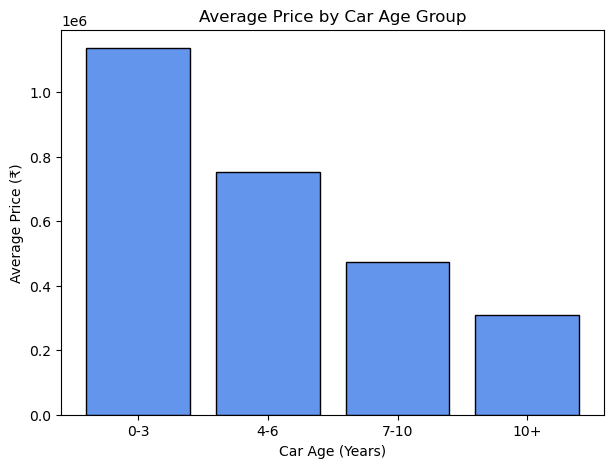

In [14]:
age_bucket_order = ['0-3', '4-6', '7-10', '10+']
age_avg = df.groupby('Age_Bucket', observed=True)['Final_Price'].mean()
age_avg = age_avg.reindex(age_bucket_order)
print(age_avg)

plt.figure(figsize=(7, 5))
plt.bar(age_avg.index, age_avg.values, color='cornflowerblue', edgecolor='black')
plt.title('Average Price by Car Age Group')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price (₹)')
plt.show()

**Observation:** Cars aged 0–3 years have the highest average price. Price drops significantly as the car gets older. This clearly shows depreciation over time.

## 12.7 City-Wise Number of Listings

City
New-delhi     391
Noida         386
Hyderabad     217
Mumbai        211
Bangalore     206
Ahmedabad     205
Pune          202
Chennai       190
Kolkata       182
Lucknow       179
Jaipur        174
Agra          155
Surat         149
Kochi         134
Coimbatore     92
Name: count, dtype: int64


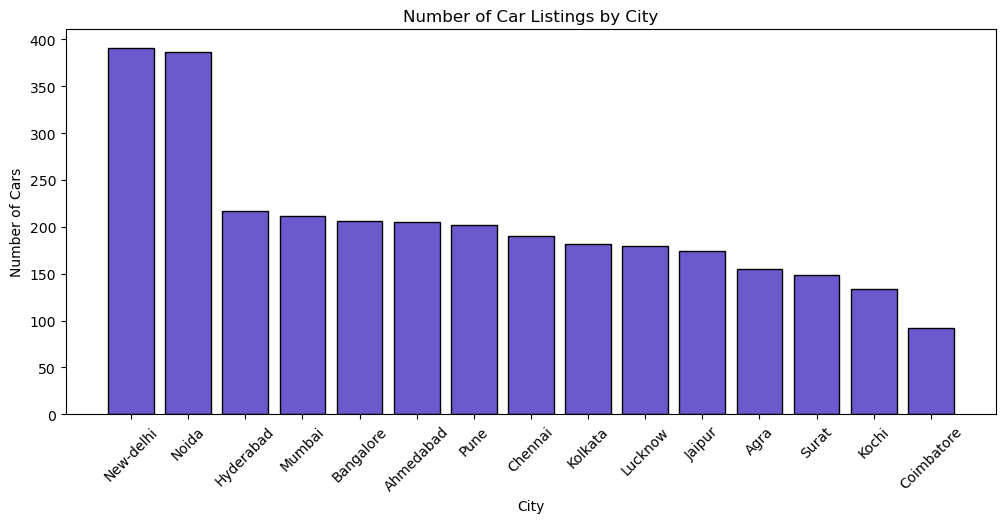

In [16]:
city_counts = df['City'].value_counts()
print(city_counts)

plt.figure(figsize=(12, 5))
plt.bar(city_counts.index, city_counts.values, color='slateblue', edgecolor='black')
plt.title('Number of Car Listings by City')
plt.xlabel('City')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

**Observation:** New Delhi and Noida have the highest number of used car listings. Smaller cities like Coimbatore and Agra have fewer listings.

# 13. Multivariate Analysis

Here we look at more than two columns together to find deeper patterns.

## 13.1 Brand-Wise Price Distribution (Box Plot)

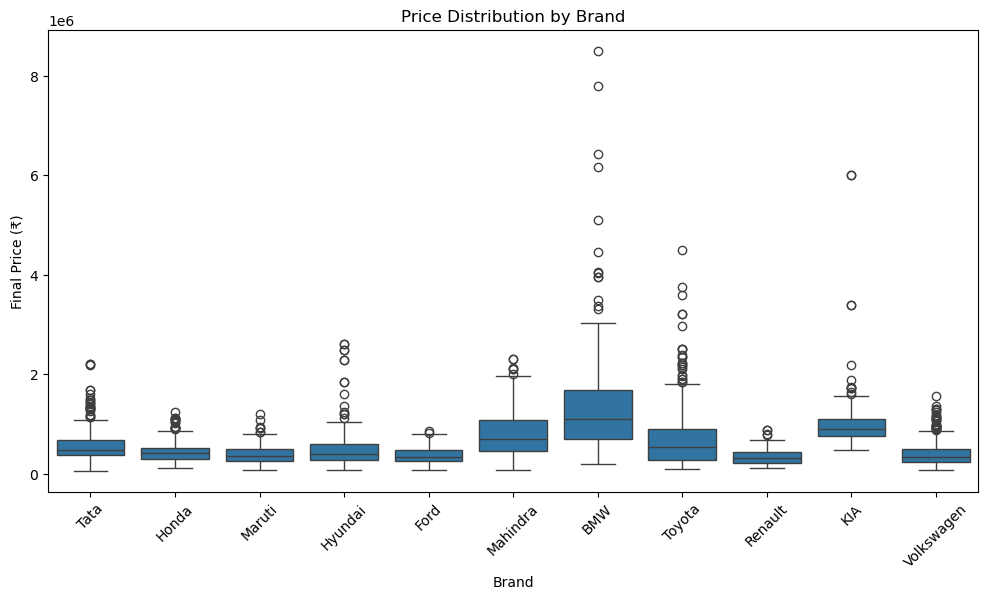

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Brand', y='Final_Price')
plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Final Price (₹)')
plt.xticks(rotation=45)
plt.show()

**Observation:** BMW shows a wide price range with many high-value outliers. Budget brands like Renault and Ford have a narrow, low price range. This clearly shows the difference in market positioning between luxury and budget brands.

## 13.2 Price by Fuel Type and Transmission (Box Plot)

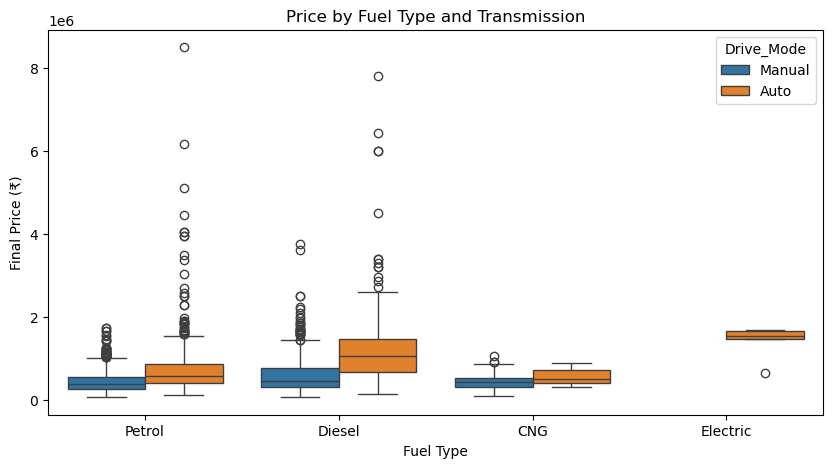

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Final_Price', hue='Drive_Mode')
plt.title('Price by Fuel Type and Transmission')
plt.xlabel('Fuel Type')
plt.ylabel('Final Price (₹)')
plt.show()

**Observation:** For every fuel type, Automatic cars are priced higher than Manual. Diesel Automatic cars tend to have the highest price among common fuel types.

## 13.3 Correlation Heatmap

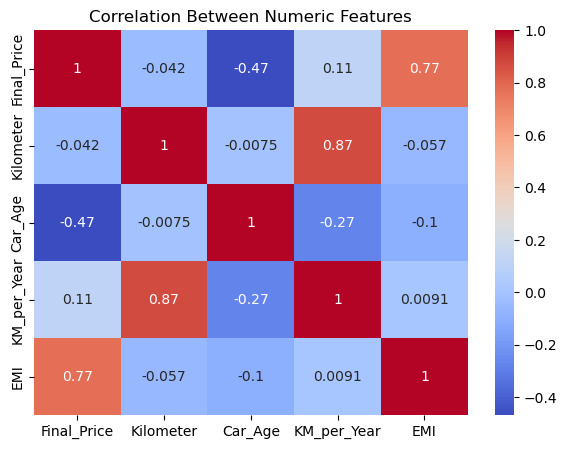

In [20]:
numeric_cols = ['Final_Price', 'Kilometer', 'Car_Age', 'KM_per_Year', 'EMI']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

**Observation:** EMI has a very strong positive correlation with Final Price (as expected, since EMI is calculated from price). Car Age and Kilometer have a negative correlation with price — older cars and high-mileage cars cost less.

## 13.4 Price Segment by Brand (Count Plot)

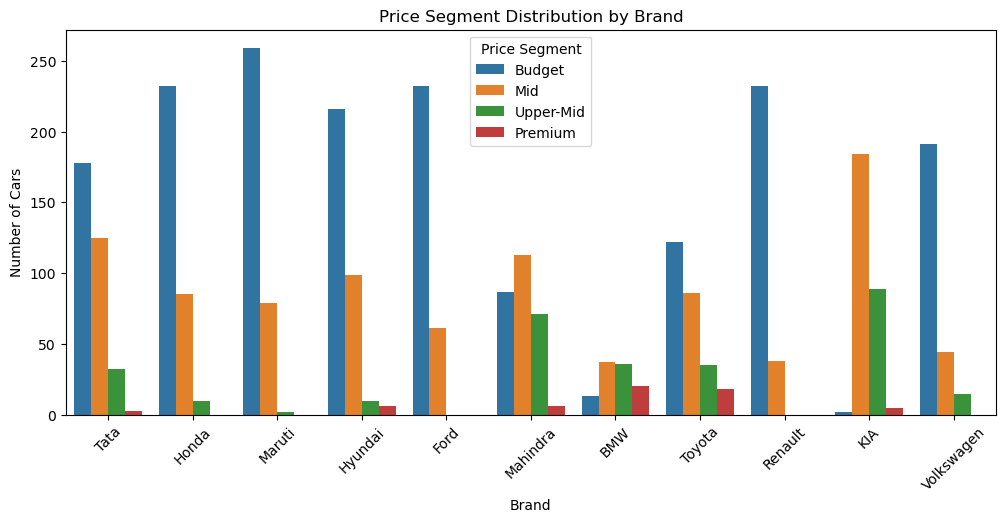

In [21]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Brand', hue='Price_Segment')
plt.title('Price Segment Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.legend(title='Price Segment')
plt.show()

**Observation:** Maruti, Renault, and Ford are heavily concentrated in the Budget segment. KIA has a strong Mid and Upper-Mid presence. BMW is the only brand with significant Premium listings.

## 13.5 Brand-Wise Depreciation Over Age Buckets (Line Plot)

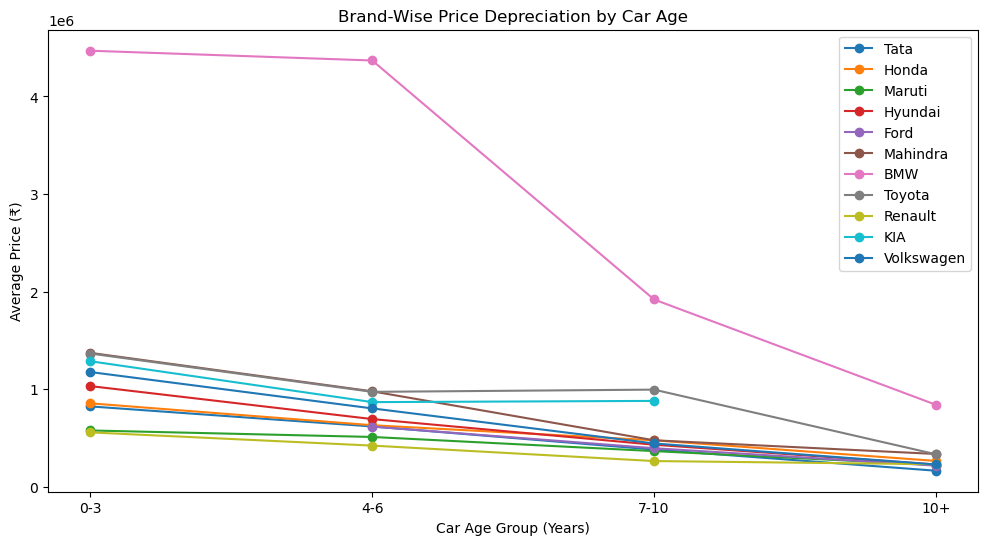

In [22]:
age_bucket_order = ['0-3', '4-6', '7-10', '10+']
brand_age = df.groupby(['Brand', 'Age_Bucket'], observed=True)['Final_Price'].mean().reset_index()

plt.figure(figsize=(12, 6))
for brand in df['Brand'].unique():
    brand_data = brand_age[brand_age['Brand'] == brand]
    brand_data = brand_data.set_index('Age_Bucket').reindex(age_bucket_order)
    plt.plot(age_bucket_order, brand_data['Final_Price'].values, marker='o', label=brand)

plt.title('Brand-Wise Price Depreciation by Car Age')
plt.xlabel('Car Age Group (Years)')
plt.ylabel('Average Price (₹)')
plt.legend()
plt.show()

**Observation:** All brands show a downward trend as car age increases. BMW's line is much higher than others but also drops steeply. Toyota holds its value better compared to budget brands like Renault and Ford at older ages.

## 13.6 Fuel Type Distribution by Brand (Count Plot)

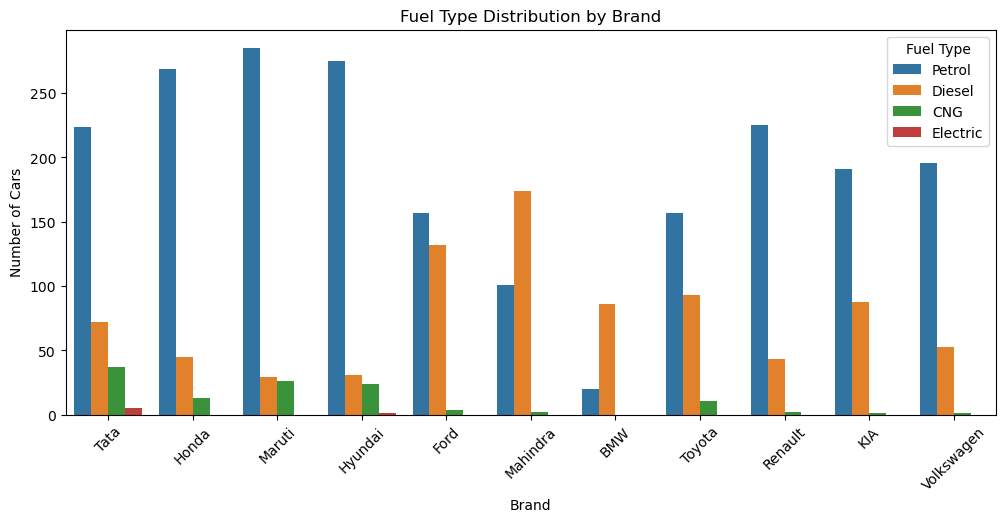

In [23]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Brand', hue='Fuel_Type')
plt.title('Fuel Type Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.legend(title='Fuel Type')
plt.show()

**Observation:** Maruti and Renault are almost entirely petrol-based. Toyota and Mahindra have more diesel cars due to their SUV and MPV models. Electric cars are very rare across all brands.

# 14. Business Insights & Conclusions

After completing the full EDA, here are the key findings from the Cars24 used car dataset:

### 1. Market is Budget-Dominated
- More than 57% of all listings fall under the Budget segment (below ₹5 Lakhs).
- Only about 2% of cars are in the Premium segment.

### 2. Brand Affects Resale Value a Lot
- BMW has the highest average resale price (around ₹15.7 Lakhs).
- Renault and Ford have the lowest resale values — they depreciate faster.
- Toyota retains its value better than other mass-market brands.

### 3. Car Age and Kilometers are Key Factors
- Older cars and high-mileage cars are priced much lower.
- Cars aged 0–3 years and driven less than 30,000 km get the best prices.

### 4. Automatic Cars Fetch Higher Price
- Automatic cars cost nearly 92% more on average than Manual cars.
- Buyers are willing to pay a premium for convenience.

### 5. Petrol Dominates, But Diesel Costs More
- 68% of cars are petrol-based, showing petrol's popularity for daily city use.
- Diesel cars are priced higher due to better fuel economy for long drives.

### 6. Delhi-NCR is the Biggest Market
- New Delhi and Noida together account for the most listings — showing the size of the NCR used car market.

### Recommendations
- **Buyers:** Look for 4–6 year old cars with 30–60K km for best value.
- **Sellers:** List cars before crossing 60,000 km to get better prices.
- **Investors:** KIA and Toyota hold value well — good choices for resale-focused buying.
